### The classification process adopts mulitple GPUs. The actual process was run on the HPC.
- The path should be adjusted when running the code in HPC.

In [2]:
import os
import pandas as pd
import gc

In [ ]:
# Load the fine-tuned model and tokenizer
tokenizer = BertTokenizer.from_pretrained('D:/Dropbox/Dropbox/vs_cloud/Job_posting_data/bert-base-chinese/')
model = BertForSequenceClassification.from_pretrained('F:/Data/job_posting/processed/model/')

# Set the device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Check if there are multiple GPUs available
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    # If so, wrap the current model in nn.DataParallel to use multiple GPUs.
    model = torch.nn.DataParallel(model)

# Load the mappings
df = pd.read_csv("F:/Data/job_posting/processed/finetune/est_sample.csv", encoding = "utf_8_sig", on_bad_lines='skip', encoding_errors='ignore')
df['soc_code'] = df['soc_code'].str.replace('-', '')
unique_soc_codes = sorted(df['soc_code'].unique())
soc_code_dict  = {soc_code: i for i, soc_code in enumerate(unique_soc_codes)}
inverse_soc_code_dict = {v: k for k, v in soc_code_dict.items()}

del df
gc.collect()

In [ ]:
# The file is already generated and exported, this cell block does not need to be run again

directory = 'F:/Data/job_posting/mapped_job_posting/Update file/'
dfPosting = pd.DataFrame()

batch_size = 1200  # Adjust as necessary

for filename in os.listdir(directory):
    if filename.startswith("job_res_"):
        f = os.path.join(directory, filename)
        df = pd.read_csv(f, encoding = "utf_8_sig", on_bad_lines='skip', delimiter= "?", encoding_errors='ignore')
        df.rename(columns={'招聘ID': '招聘主键ID'}, inplace=True)
        df = df[['招聘主键ID', '公司ID', '发布日期', '工作描述', '工作名称', '行业名称']]
        repeat_title = 2  # Adjust this value to control the importance of the title
        df['input_text'] = (df['工作名称'] + ' ') * repeat_title + df['工作描述']

        num_examples = len(df['input_text'])

        for i in range(0, num_examples, batch_size):
            batch_text = df['input_text'][i:i+batch_size].astype(str).tolist()
            inputs = tokenizer(batch_text, padding=True, truncation=True, max_length=512, return_tensors='pt')

            inputs = {name: tensor.to(device) for name, tensor in inputs.items()}
            
            with torch.no_grad():
                outputs = model(**inputs)

            predictions = torch.argmax(outputs.logits, dim=-1)
            predictions_list = predictions.cpu().numpy().tolist()
            original_soc_codes = [inverse_soc_code_dict[pred] for pred in predictions_list]

            df.loc[i:i+batch_size-1, 'predicted_soc_code'] = original_soc_codes

            torch.cuda.empty_cache()

        df.drop(['行业名称', '工作描述', 'input_text'], axis=1, inplace=True)
        df.to_csv('F:/Data/job_posting/processed/estimation/{}'.format(filename), index=False, encoding='utf_8_sig')


### Append all the files with the classified occupation titles.

In [2]:
# read and append all the csv files in folder 'G:\Data\job_post_mapping2' to one dataframe named 'dfPosting'

# define the directory
directory = 'G:/Data/job_posting_mapping2/'

# define a list to store DataFrames
dfs = []

# iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.endswith('.csv'):  # check if the file is a csv
        # construct full file path
        file_path = os.path.join(directory, filename)
        # read the csv file and append it to the dfs list
        dfs.append(pd.read_csv(file_path))

# concatenate all DataFrames in the list
dfPosting = pd.concat(dfs, ignore_index=True)

# print the dataframe
print(dfPosting)

             招聘主键ID       公司ID        发布日期            工作名称  predicted_soc_code
0            133574  160653372  2018-12-18     人事文员长白班五险一金              434150
1            133575   68152903  2018-12-19     招聘专员/高级招聘专员              131070
2            133576  175185856  2018-12-18           资产管理员              119010
3            133577   57572702  2018-12-18            行政人事              131070
4            133578   43730331  2018-12-18       人力资源专员/助理              113120
...             ...        ...         ...             ...                 ...
99315436  110327928   40642503  2018-06-29  保险培训师、央企诚招培训讲师              259030
99315437  110327930   48482812  2018-06-29          人力资源总监              113120
99315438  110327931   34459898  2018-06-29   行政专员(纯文职，可实习)              436010
99315439  110327932   56272790  2018-06-29      中国人寿售后服务专员              434050
99315440  110327933    1013142  2018-06-29          理财管理主管              113030

[99315441 rows x 5 columns]


In [3]:
# keep year-month only in the column '发布日期'
dfPosting['发布日期'] = dfPosting['发布日期'].str[:7]

# calculate frequency distribution
freq_dist = dfPosting['发布日期'].value_counts()

# print the frequency distribution
print(freq_dist)

# number of unique values in the column '发布日期' within each year

# Create a new column that contains the year of each release date
dfPosting['year'] = dfPosting['发布日期'].str[:4]

# Group the DataFrame by year and count the number of unique release dates in each group
result = dfPosting.groupby('year')['发布日期'].nunique()

# Print the result
print(result)

# drop if 'year' is 2016 or 2021
dfPosting = dfPosting[dfPosting['year'] != '2020']
dfPosting = dfPosting[dfPosting['year'] != '2021']

# convert the column '发布日期' to quarterly
dfPosting['发布日期'] = pd.to_datetime(dfPosting['发布日期'])
dfPosting['发布日期'] = dfPosting['发布日期'].dt.to_period('Q')

# drop column '工作名称' 
dfPosting.drop(['工作名称', '公司ID'], axis=1, inplace=True)

# rename 'predicted_soc_code' as 'soc_code'
dfPosting.rename(columns={'predicted_soc_code': 'soc_code'}, inplace=True)

发布日期
2017-03    5898254
2018-07    4553896
2017-02    3735209
2017-06    3514919
2017-05    3241251
            ...   
2021-05     210628
2016-10     180696
2016-05     119262
2021-08       6073
2016-11         86
Name: count, Length: 64, dtype: int64
year
2016     8
2017    12
2018    12
2019    12
2020    12
2021     8
Name: 发布日期, dtype: int64


### Plot the frequency distribution by year-quarter.

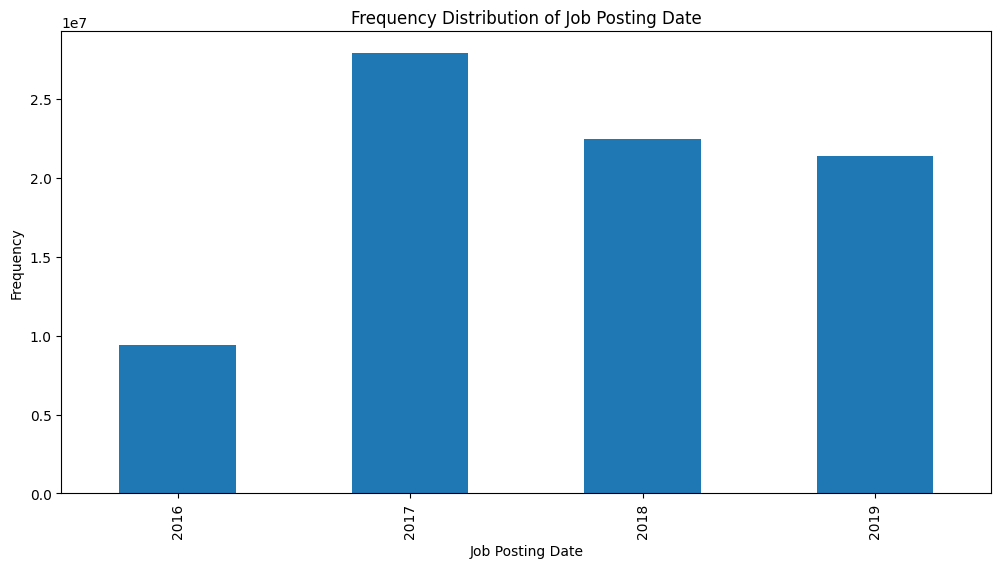

In [5]:
import matplotlib.pyplot as plt

# calculate frequency distribution
freq_dist = dfPosting['year'].value_counts()

# sort the frequency distribution by index (i.e., by date)
freq_dist = freq_dist.sort_index()

# plot the frequency distribution
freq_dist.plot(kind='bar', figsize=(12,6))

plt.title('Frequency Distribution of Job Posting Date')
plt.xlabel('Job Posting Date')
plt.ylabel('Frequency')
plt.show()


### Load the data with `data programming tech` indicator, and merge with the job posting title data.
- The `data programming tech` indicator is create from keywords_preparing.ipynb.

- Different versions of job posting keyword: 'posting_dataprog' is the short one exclude the excel, word and so on. 'posting_dataprog_fullkey' is the complete list.
- `Firm registration data:`
- 'firm_regis_spatial3' largely follows the data cleaning process by 'firm_regis_spatial2'. However, we use the new dataset from RESSET: a more complete firm list (new firm ID indicator to represent same firm changes names), and we have a better way to define branches.
- 'firm_regis_spatial2' is the complete one (seems to be the correct one). 
- 'firm_regis_spatial' is the one with more strict filtering criteria.

In [ ]:
# The `data programming tech` indicator is create from keywords_preparing.ipynb.
dfProgram = pd.read_csv('G:/Data/job_posting/processed/estimation/posting_dataprogfull.csv', encoding='utf-8')
 
# merge 'dfProgram' with 'dfPosting' on '招聘主键ID', keep matched sample only
dfPosting = pd.merge(dfPosting, dfProgram, on='招聘主键ID', how='inner')

# generate column 'posting_count` with all values equal to 1
dfPosting['posting_count'] = 1
dfPosting

,招聘主键ID,发布日期,soc_code,year,公司ID,data_software,Accounting software_Safe_0,Accounting software_Safe_1,Analytical or scientific software_Safe_0,Business intelligence and data analysis software_Safe_1,...,Enterprise resource planning ERP software_China_0,Enterprise resource planning ERP software_China_1,Medical software_China_0,Medical software_China_1,Metadata management software_China_0,Object or component oriented development software_China_0,Object oriented data base management software_China_0,Program testing software_China_0,Web platform development software_China_0,posting_count
0,133574,2018Q4,434150,2018,160653372,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,133575,2018Q4,131070,2018,68152903,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,133576,2018Q4,119010,2018,175185856,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,133577,2018Q4,131070,2018,57572702,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,133578,2018Q4,113120,2018,43730331,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81092784,110327928,2018Q2,259030,2018,40642503,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
81092785,110327930,2018Q2,113120,2018,48482812,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
81092786,110327931,2018Q2,436010,2018,34459898,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
81092787,110327932,2018Q2,434050,2018,56272790,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [5]:
# Given mapping of commodity names to class titles
commodity_to_class = {
    'Web platform development software': 'Development software',
    'Data base management system software': 'Data management and query software',
    'Data base user interface and query software': 'Data management and query software',
    'Development environment software': 'Development software',
    'Business intelligence and data analysis software': 'Data management and query software',
    'Enterprise application integration software': 'Development software',
    'Computer aided design CAD software': 'Industry specific software',
    'Object or component oriented development software': 'Development software',
    'Configuration management software': 'Development software',
    'Medical software': 'Industry specific software',
    'Object oriented data base management software': 'Data management and query software',
    'Analytical or scientific software': 'Industry specific software',
    'Metadata management software': 'Data management and query software',
    'Program testing software': 'Development software',
    'Enterprise resource planning ERP software': 'Finance accounting and enterprise resource planning ERP software',
    'Data base reporting software': 'Data management and query software',
    'Accounting software': 'Finance accounting and enterprise resource planning ERP software'
}

# Example list of class categories
class_categories = [
    'Finance accounting and enterprise resource planning ERP software',
    'Data management and query software',
    'Development software',
    'Industry specific software'
]

# Create new columns in dfPosting for each class category, initialized to 0
for category in class_categories:
    dfPosting[category] = 0

# Iterate over the commodity_to_class mapping
for commodity, class_category in commodity_to_class.items():
    # Find columns that contain the commodity name
    commodity_columns = [col for col in dfPosting.columns if commodity in col]
    # Create a mask where any of the commodity columns is 1 or more
    mask = dfPosting[commodity_columns].max(axis=1) >= 1
    # Update the corresponding class category column
    dfPosting.loc[mask, class_category] = 1

In [6]:
# Filtering columns based on the specified suffixes ('_Safe_0', '_Safe_1', 'China_0', 'China_1')
suffixes = ['_Safe_0', '_Safe_1', '_China_0', '_China_1']
groups = {suffix: [col for col in dfPosting.columns if col.endswith(suffix)] for suffix in suffixes}

# Creating new columns (ds_safe0, ds_safe1, ds_cn0, ds_cn1) to represent if any column within each group has a value >= 1
# Filling the new columns with dummy variables (0 or 1)
new_columns = {'ds_safe0': '_Safe_0', 'ds_safe1': '_Safe_1', 'ds_cn0': '_China_0', 'ds_cn1': '_China_1'}

# We use the .any() function to quickly check if any value in a row along specified columns is >= 1
# This is more efficient than using .sum() on large datasets

for new_col, suffix in new_columns.items():
    dfPosting[new_col] = dfPosting[groups[suffix]].any(axis=1).astype(int)

# Create new columns for storing the sum of selected columns
new_columns_sum = {'ds_safe0_sum': '_Safe_0', 'ds_safe1_sum': '_Safe_1', 'ds_cn0_sum': '_China_0', 'ds_cn1_sum': '_China_1'}
for new_col, suffix in new_columns_sum.items():
    dfPosting[new_col] = dfPosting[groups[suffix]].sum(axis=1)

# Create a new column 'data_software_sum' to record the sum of the newly generated columns
sum_columns = list(new_columns_sum.keys())
dfPosting['data_software_sum'] = dfPosting[sum_columns].sum(axis=1)

# Removing all columns related to software skills that end with '_Safe_0', '_Safe_1', 'China_0', or 'China_1'
columns_to_remove = [col for suffix in suffixes for col in groups[suffix]]
dfPosting.drop(columns=columns_to_remove, inplace=True)

# Showing the first few rows to confirm the changes
dfPosting.head()

# export to ''G:/Data/job_posting/processed/estimation/posting_program.csv'' 
dfPosting.to_csv('G:/Data/job_posting/processed/estimation/posting_program.csv', index=False, encoding='utf-8')

,招聘主键ID,发布日期,soc_code,year,公司ID,data_software,posting_count,Finance accounting and enterprise resource planning ERP software,Data management and query software,Development software,Industry specific software,ds_safe0,ds_safe1,ds_cn0,ds_cn1,ds_safe0_sum,ds_safe1_sum,ds_cn0_sum,ds_cn1_sum,data_software_sum
0,133574,2018Q4,434150,2018,160653372,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,133575,2018Q4,131070,2018,68152903,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,133576,2018Q4,119010,2018,175185856,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,133577,2018Q4,131070,2018,57572702,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,133578,2018Q4,113120,2018,43730331,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Due to the sample size is too late for local computer's memory (128G), we move the above code to `HPC`.
- Now, load the file (`posting_program`) after the calculation is done.

In [2]:
# load the dataframe back
dfPosting = pd.read_csv('G:/Data/job_posting/processed/estimation/posting_program.csv', encoding='utf-8')
# drop if year is 2016
dfPosting = dfPosting[dfPosting['year'] != 2016]
dfPosting.head()

,招聘主键ID,发布日期,soc_code,year,公司ID,data_software,posting_count,Finance accounting and enterprise resource planning ERP software,Data management and query software,Development software,Industry specific software,ds_safe0,ds_safe1,ds_cn0,ds_cn1,ds_safe0_sum,ds_safe1_sum,ds_cn0_sum,ds_cn1_sum,data_software_sum
0,133574,2018Q4,434150,2018,160653372,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,133575,2018Q4,131070,2018,68152903,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,133576,2018Q4,119010,2018,175185856,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,133577,2018Q4,131070,2018,57572702,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,133578,2018Q4,113120,2018,43730331,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


### Load the `firm registration` data, and merge with the `dfPosting`, and export the final data for future usage.

- `firm registration` data is generated from `firm_reg_v2.ipynb`
- `dfPosting` includes '招聘主键ID', '公司ID', '发布日期', 'soc_code', 'year', 'software_data', 'posting_count'.

In [3]:
# load the dataframe back
filtered_dataframe2 = pd.read_csv('G:/Data/job_posting/processed/estimation/firm_regis_spatial3.csv', encoding='utf-8')
filtered_dataframe2 = filtered_dataframe2.drop(filtered_dataframe2[(filtered_dataframe2['firm_status'] == 'closed') & (filtered_dataframe2['核准日期_approvedTime'] < '2017-01-01')].index)
# drop '经营范围_businessScope', '企业名称_companyName' to save memory
filtered_dataframe2.drop(['企业名称_companyName', '企业类型'], axis=1, inplace=True)
# rename '公司主键_companyId' as '公司ID'
filtered_dataframe2.rename(columns={'公司主键_companyId': '公司ID'}, inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15324\741964179.py:2: DtypeWarning: Columns (0,9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_dataframe2 = pd.read_csv('G:/Data/job_posting/processed/estimation/firm_regis_spatial3.csv', encoding='utf-8')


In [4]:
# merge 'filtered_dataframe2' and 'dfPosting' on '公司ID', keep matched and observations from 'filtered_dataframe2'
filtered_dataframe2 = pd.merge(filtered_dataframe2, dfPosting, on='公司ID', how='left')
filtered_dataframe2

#del dfPosting
#gc.collect()

,公司ID,省份_province,城市_city,一级行业_categoryStrBig,二级行业_categoryStrMiddle,注册时间_estiblishTime,企业类型_companyOrgType,核准日期_approvedTime,新公司主键New_id,firm_status,...,Industry specific software,ds_safe0,ds_safe1,ds_cn0,ds_cn1,ds_safe0_sum,ds_safe1_sum,ds_cn0_sum,ds_cn1_sum,data_software_sum
0,10000,北京,北京市,批发和零售业,批发业,2001-05-17,有限责任公司(自然人投资或控股),2020-06-13,0,closed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,北京,北京市,建筑业,建筑装饰、装修和其他建筑业,2008-09-11,有限责任公司(自然人独资),2017-11-03,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10002,北京,北京市,科学研究和技术服务业,科技推广和应用服务业,2003-05-14,有限责任公司(自然人投资或控股),2023-05-23,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10004,北京,北京市,科学研究和技术服务业,科技推广和应用服务业,2003-09-28,有限责任公司(自然人投资或控股),2023-05-08,0,run,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10004,北京,北京市,科学研究和技术服务业,科技推广和应用服务业,2003-09-28,有限责任公司(自然人投资或控股),2023-05-08,0,run,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116889068,358007050,NaN,NaN,金融业,资本市场服务,2017-07-07,有限责任公司,2023-05-06,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116889069,358007051,浙江,宁波市,租赁和商务服务业,商务服务业,2017-02-23,有限责任公司,2023-04-23,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116889070,358007055,山东,青岛市,金融业,保险业,2018-12-29,股份有限公司分公司,2023-06-21,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116889071,358007067,NaN,NaN,科学研究和技术服务业,科技推广和应用服务业,2017-01-16,有限责任公司,2023-07-03,0,run,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# unique values in the column '公司ID' if '招聘主键ID' is NOT Null
print(filtered_dataframe2['公司ID'][filtered_dataframe2['招聘主键ID'].notnull()].nunique())
print(filtered_dataframe2['招聘主键ID'].nunique())
print(dfPosting['公司ID'].nunique())
print(dfPosting['招聘主键ID'].nunique())

3541851
67791993
4223553
71662227


In [12]:
# track the size of the dataset to prevent memory burst 

# get the memory usage of each column
memory_usage = filtered_dataframe2.memory_usage(deep=True)

# get the total memory usage
total_memory_usage = memory_usage.sum()
# print the total memory usage in bytes
print('Memory usage in bytes:', total_memory_usage)

# convert bytes to megabytes (1 byte = 1.0e-6 megabytes)
total_memory_usage_mb = total_memory_usage * 1.0e-6
# print the total memory usage in megabytes
print('Memory usage in MB:', total_memory_usage_mb)

Memory usage in bytes: 126342706102
Memory usage in MB: 126342.706102


### The master dataframe `filtered_dataframe2` includes firm registration, standardized occupation code, and the `data programming tech` indicator.
- simple data cleaning: drop observations with `省份_province` cannot be identified.
- repalce `城市_city` with `省份_province` if `省份_province` is `北京`, or `上海`, or `天津`, or `重庆`
- by `year` and `省份_province`, and `城市_city`, we require at least 5000 jobs are posted online to exclude very inactive and arbitrary markets to be included in the sample.  

In [13]:
# # Read the master dataframe and work on it
# #filtered_dataframe2 = pd.read_csv('F:/Data/job_posting/processed/estimation/spatial_tech_diffusion.csv', encoding='utf_8_sig')

# # drop if '省份_province' is null
filtered_dataframe2 = filtered_dataframe2[filtered_dataframe2['省份_province'].notnull()]

# # repalce '城市_city' with '省份_province' if '省份_province' is '北京', or '上海', or '天津', or '重庆'
# filtered_dataframe2.loc[filtered_dataframe2['省份_province'] == '北京', '城市_city'] = '北京市'
# filtered_dataframe2.loc[filtered_dataframe2['省份_province'] == '上海', '城市_city'] = '上海市'
# filtered_dataframe2.loc[filtered_dataframe2['省份_province'] == '天津', '城市_city'] = '天津市'
# filtered_dataframe2.loc[filtered_dataframe2['省份_province'] == '重庆', '城市_city'] = '重庆市'

In [14]:
# number of observations with 'branch' == 1 in 'filtered_dataframe2' 
# (i.e. number of observations with 'branch' == 1 in 'filtered_dataframe2')
print(filtered_dataframe2[filtered_dataframe2['branch'] == 1].shape[0])
print(filtered_dataframe2[filtered_dataframe2['parent'] == 1].shape[0])
print(filtered_dataframe2[filtered_dataframe2['local'] == 1].shape[0])

7898766
20078338
96704851


In [15]:
# # generate a new dataframe 'dfProgram' as the sum of the 'filtered_dataframe2' column 'posting_count' by 'year' and '省份_province', and '城市_city'
# dfProgram = filtered_dataframe2.groupby(['year', '省份_province', '城市_city'])['posting_count'].sum().reset_index()
# # drop if posting_count < 1000
# #dfProgram = dfProgram[dfProgram['posting_count'] >= 3000]
# # keep columns '省份_province' and '城市_city'
# dfProgram = dfProgram[['省份_province', '城市_city']]
# # drop duplicates
# dfProgram.drop_duplicates(inplace=True)
# # merge dfProgram with filtered_dataframe2 on '省份_province' and '城市_city', keep matched sample only
# filtered_dataframe2 = pd.merge(filtered_dataframe2, dfProgram, on=['省份_province', '城市_city'], how='inner')

In [16]:
# # number of observations with 'branch' == 1 in 'filtered_dataframe2' 
# # (i.e. number of observations with 'branch' == 1 in 'filtered_dataframe2')
# print(filtered_dataframe2[filtered_dataframe2['branch'] == 1].shape[0])
# print(filtered_dataframe2[filtered_dataframe2['parent'] == 1].shape[0])
# print(filtered_dataframe2[filtered_dataframe2['local'] == 1].shape[0])

#### Different final versions have been generated:

- spatial_tech_diffusion5 is the merged 'posting_dataprog' and 'firm_regis_spatial3', incorporating the classes of the technologies. See changes in `dfPosting`
- spatial_tech_diffusion4 is the merged 'posting_dataprog' and 'firm_regis_spatial3'.
- spatial_tech_diffusion3 is the merged 'posting_dataprog' and 'firm_regis_spatial2'.
- spatial_tech_diffusion2 is the merged 'posting_dataprog_fullkey' and 'firm_regis_spatial2'.
- spatial_tech_diffusion is the merged 'posting_dataprog_fullkey' and 'firm_regis_spatial'.

In [17]:
# export to csv at folder `F:/Data/job_posting/processed/estimation/`, the dataframe has been exported. Do not run this line again
filtered_dataframe2.to_csv('G:/Data/job_posting/processed/estimation/spatial_tech_diffusion5.csv', index=False, encoding='utf_8_sig')